[ WARN:0@0.422] global loadsave.cpp:278 findDecoder imread_('obj/cat/foto_10.png'): can't open/read file: check file path/integrity


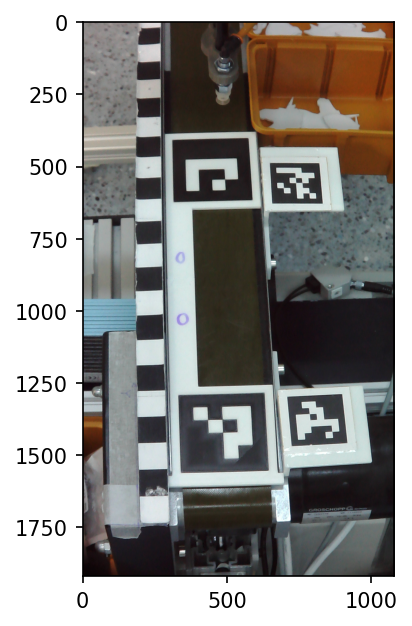

In [2]:
import cv2 as cv
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from cv2 import aruco
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150

aruco_dict = aruco.getPredefinedDictionary(aruco.DICT_4X4_100)
parameters = aruco.DetectorParameters()
detector = aruco.ArucoDetector(aruco_dict, parameters)

img_aruco = cv.imread('aruco_pic/foto_0.png')
img_aruco_rotated = cv.rotate(img_aruco,2)

# Test Bild
img_obj = cv.imread('obj/cat/foto_10.png')
img_obj = cv.imread('obj/unicorn/foto_107.png')
img_obj_rotated = cv.rotate(img_obj,2)

SRC_COORDS = (np.array([[[ -44.,  246.],  [-102., 244.],   [-102., 304.],  [ -44.,304.], 
                                [ -44., 222 + 246.], [-102., 222 + 246.], [-102., 282. + 244], [ -44., 282. + 244]]], dtype= np.float32))


SRC_COORDS_2 = np.array([[[0.246, -0.044], [0.244, -0.102], [0.304, -0.102], [0.304, -0.044],
                          [0.468, -0.044], [0.466, -0.102], [0.526, -0.102], [0.528, -0.044]]], dtype=np.float32)

x1_initial = 246. # mm
y1_initial = -44. # mm

x2_initial = 244. # mm
y2_initial = -102. # mm

x3_initial = 304. # mm
y3_initial = -102. # mm

offset_second_marker_1 = 222.
offset_second_marker_2 = 282.

SRC_COORDS2 = (np.array([[[y1_initial, x1_initial],  [y2_initial, x2_initial],  [y3_initial, x3_initial],  [x1_initial, x3_initial], 
                                [y1_initial, x1_initial + offset_second_marker_1], [y2_initial, x2_initial + offset_second_marker_1], [y2_initial, x2_initial + offset_second_marker_2], [y1_initial, x1_initial + offset_second_marker_2]]], dtype= np.float32))

plt.imshow(img_aruco_rotated)

# Bildauschnitt errechnen und segmentierung einstellen

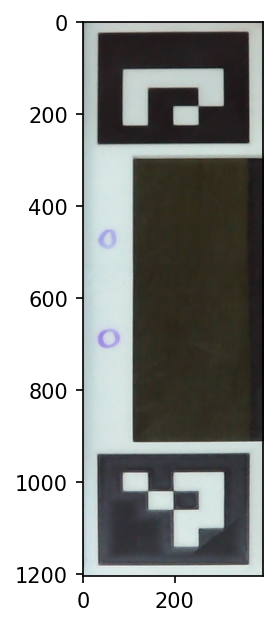

In [3]:
corners, ids, rejected = detector.detectMarkers(img_aruco_rotated)

ids_list = ids.flatten().tolist()

if 1 not in ids_list or 0 not in ids_list:
    print('Fehler: Die benötigten Marker (ID 1 und ID 0) sind nicht beide im Bild!')

idx_1 = ids_list.index(1)
idx_0 = ids_list.index(0)

sorted_corners = [corners[idx_1], corners[idx_0]]

dstPoints = np.concatenate(sorted_corners, axis=1)

H_pre, _ = cv.findHomography(srcPoints=SRC_COORDS_2, dstPoints=dstPoints, method=0)
H_pre_inv = np.linalg.inv(H_pre)

pts1 = np.float32([
    sorted_corners[0][0][0],  # ID 1 (oben-links)  
    sorted_corners[0][0][1],  # ID 1 (oben-rechts)
    sorted_corners[1][0][3],  # ID 0 (unten-links) 
    sorted_corners[1][0][2],  # ID 0 (unten-rechts)
])

pts1_reshaped = pts1.astype(np.float32).reshape(-1, 1, 2)

world_frame = cv.perspectiveTransform(pts1_reshaped, H_pre_inv)

offset_raw = np.array([
    [-0.006, +0.006],  # mm - X offset -6, Y offset -6
    [-0.006, -0.006],  # mm - X offset +6, Y offset -6
    [+0.006, +0.006],  # mm - X offset -6, Y offset +6
    [+0.006, -0.006]   # mm - X offset +6, Y offset +6
], dtype=np.float32)

offset = offset_raw.reshape(-1, 1, 2)
pts1_2 = world_frame + offset

pts1_2_pixel = cv.perspectiveTransform(pts1_2, H_pre)

min_x = np.min(pts1_2_pixel[:, 0, 0])
max_x = np.max(pts1_2_pixel[:, 0, 0])
min_y = np.min(pts1_2_pixel[:, 0, 1])
max_y = np.max(pts1_2_pixel[:, 0, 1])

width = int(max_x - min_x)
height = int(max_y - min_y)

pts2_proportional = np.float32([
    [0, 0],
    [width, 0],
    [0, height],
    [width, height]
])
M_for_all = cv.getPerspectiveTransform(pts1_2_pixel, pts2_proportional)

img_warped = cv.warpPerspective(img_aruco_rotated, M_for_all, (width, height))
plt.imshow(img_warped)

In [4]:
corners, ids, rejected = detector.detectMarkers(img_warped)

dstPoints = np.concatenate(corners, axis=1)
H, _ = cv.findHomography(srcPoints=SRC_COORDS_2, dstPoints=dstPoints, method=0)
H_inv = np.linalg.inv(H)

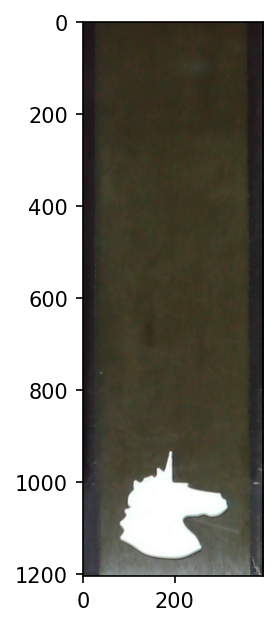

In [5]:
dst_obj = cv.warpPerspective(img_obj_rotated, M_for_all, (width, height))
plt.imshow(dst_obj)

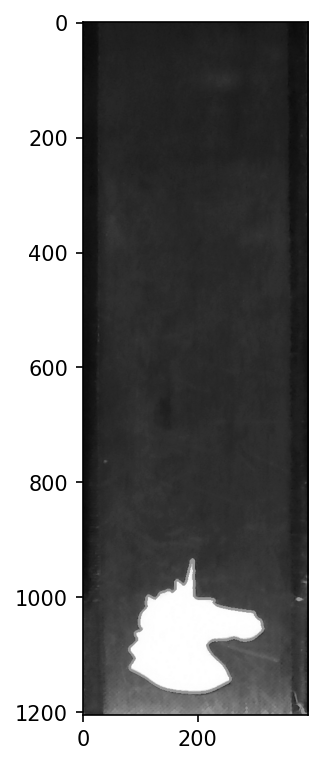

In [6]:
gray_image = cv.cvtColor(dst_obj, cv.COLOR_BGR2GRAY)

ret , img_thresh = cv.threshold(gray_image, 150, 255,cv.THRESH_BINARY + cv.THRESH_OTSU)

uint8_img_thresh = img_thresh.astype(np.uint8)

contours_obj , hierarchy = cv.findContours(uint8_img_thresh, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)

img_with_contours = gray_image.copy()

cv.drawContours(img_with_contours, contours_obj, contourIdx= -1 , color= (155, 155, 155),thickness=3)

plt.figure(figsize=(8, 6))
plt.imshow(img_with_contours, cmap='gray')

In [7]:
cwd = Path.cwd()

candidate_paths = [
    cwd / "obj",
    cwd / "misc" / "prepWork" / "dev_pictures" / "obj",
    cwd / "dev_pictures" / "obj",
]

for path in candidate_paths:
    if path.exists():
        DATA_PATH = path
        break
else:
    raise FileNotFoundError(
        f"DATA_PATH not found. Checked: {candidate_paths} (cwd={cwd})"
    )

print("Using DATA_PATH:", DATA_PATH)

Using DATA_PATH: /home/lbraun/Robotik/4_Semester/robotik_projekt_3/Portal-zur-Exmatrikulation/misc/prepWork/dev_ml/v3/obj


In [8]:
def warp_image(img):
    img_rotated = cv.rotate(img, 2)
    dst_obj = cv.warpPerspective(img_rotated, M_for_all, (width, height))
    return dst_obj

def rotate_contour(cnt, angle):
    """Rotiert eine Kontur um ihren eigenen Mittelpunkt."""
    M_moments = cv.moments(cnt)
    if M_moments["m00"] == 0:
        return cnt
    cx = M_moments["m10"] / M_moments["m00"]
    cy = M_moments["m01"] / M_moments["m00"]

    angle_rad = np.deg2rad(angle)
    cos_a, sin_a = np.cos(angle_rad), np.sin(angle_rad)

    pts = cnt[:, 0, :].astype(np.float32)
    pts_centered = pts - np.array([cx, cy])
    pts_rotated = np.column_stack([
        pts_centered[:, 0] * cos_a - pts_centered[:, 1] * sin_a,
        pts_centered[:, 0] * sin_a + pts_centered[:, 1] * cos_a
    ]) + np.array([cx, cy])

    return pts_rotated.astype(np.int32).reshape(-1, 1, 2)

def mirror_contour(cnt, img_width):
    """Spiegelt eine Kontur horizontal."""
    pts = cnt[:, 0, :].astype(np.float32)
    pts[:, 0] = img_width - pts[:, 0]
    return pts.astype(np.int32).reshape(-1, 1, 2)

In [9]:
def extract_main_contour(img):

    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    _, thresh = cv.threshold(gray, 150, 255, cv.THRESH_BINARY)

    uint8_img_thresh = thresh.astype(np.uint8)

    contours, _ = cv.findContours(uint8_img_thresh, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return None

    return max(contours, key=cv.contourArea)

In [10]:
def extract_features(cnt):

    features = {}

    area = cv.contourArea(cnt)
    perimeter = cv.arcLength(cnt, True)

    if area == 0 or perimeter == 0:
        return None

    features["area"] = area
    features["perimeter"] = perimeter

    # Shape approx
    epsilon = 0.04 * perimeter
    approx = cv.approxPolyDP(cnt, epsilon, True)
    features["corners"] = len(approx)

    # Bounding box
    x, y, w, h = cv.boundingRect(cnt)

    features["aspect_ratio"] = w / h
    features["bbox_w"] = w
    features["bbox_h"] = h

    # Circularity
    features["circularity"] = (4 * np.pi * area) / (perimeter ** 2)

    # Solidity
    hull = cv.convexHull(cnt)
    hull_area = cv.contourArea(hull)

    features["solidity"] = area / hull_area if hull_area > 0 else 0

    # Hu Moments
    hu_raw = cv.HuMoments(cv.moments(cnt)).flatten()

    with np.errstate(divide="ignore"):
        hu_log = -np.sign(hu_raw) * np.log10(np.abs(hu_raw) + 1e-10)

    for i in range(7):
        features[f"hu_{i}"] = float(hu_log[i])  

    # Fourier Descriptors
    contour_pts = cnt[:, 0, :]
    complex_contour = contour_pts[:, 0] + 1j * contour_pts[:, 1]
    fourier = np.fft.fft(complex_contour)

    fourier = np.abs(fourier)
    fourier = fourier[1:]    
    fourier = fourier / (fourier[0] + 1e-10)   

    N_DESCRIPTORS = 10
    for i in range(N_DESCRIPTORS):
        features[f"fd_{i+1}"] = float(fourier[i]) if i < len(fourier) else 0

    M_moments = cv.moments(cnt)
    features["symmetry"] = abs(M_moments["mu11"]) / (M_moments["mu20"] + M_moments["mu02"] + 1e-6)

    return features

In [11]:
angles = [0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330]

rows = []

In [12]:
from pathlib import Path

DEBUG_PATH = Path("debug_contours")
DEBUG_PATH.mkdir(exist_ok=True)

for class_dir in DATA_PATH.iterdir():
    if not class_dir.is_dir():
        continue

    label = class_dir.name
    print("Processing:", label)
    out_dir = DEBUG_PATH / label
    out_dir.mkdir(exist_ok=True)

    for img_path in class_dir.glob("*.png"):

        img_first = cv.imread(str(img_path))
        img = warp_image(img_first)
        if img is None:
            continue

        img_h, img_w = img.shape[:2]

        cnt_orig = extract_main_contour(img)
        if cnt_orig is None:
            print(f"⚠️ Kein Contour gefunden: {img_path.name}")
            continue

        variants = {}
        for angle in angles:
            variants[f"{img_path.stem}_rot{angle}"] = rotate_contour(cnt_orig, angle)

        cnt_mirrored = mirror_contour(cnt_orig, img_w)
        for angle in angles:
            variants[f"{img_path.stem}_mir{angle}"] = rotate_contour(cnt_mirrored, angle)

        for name, cnt in variants.items():

            contour_img = np.zeros((img_h, img_w), dtype=np.uint8)
            cv.drawContours(contour_img, [cnt], -1, 255, 2)
            x, y, bw, bh = cv.boundingRect(cnt)
            cv.rectangle(contour_img, (x, y), (x+bw, y+bh), 180, 1)
            cv.imwrite(str(out_dir / f"{name}.png"), contour_img)

            feat = extract_features(cnt)
            if feat is None:
                continue

            feat["label"] = label
            feat["name"] = name
            rows.append(feat)

print("✅ Kontur-Bilder gespeichert unter:", DEBUG_PATH.resolve())

Processing: unicorn
Processing: cat
Processing: rejected
✅ Kontur-Bilder gespeichert unter: /home/lbraun/Robotik/4_Semester/robotik_projekt_3/Portal-zur-Exmatrikulation/misc/prepWork/dev_ml/v3/debug_contours


In [13]:
df = pd.DataFrame(rows)

print("Dataset shape:", df.shape)

df.to_csv("features_dataset.csv", index=False)

df.head()

Dataset shape: (3600, 28)


,area,perimeter,corners,aspect_ratio,bbox_w,bbox_h,circularity,solidity,hu_0,hu_1,...,fd_4,fd_5,fd_6,fd_7,fd_8,fd_9,fd_10,symmetry,label,name
0,28011.0,936.631591,7,1.210784,247,204,0.401237,0.759445,0.702998,2.231863,...,0.406954,0.090888,0.088767,0.088093,0.090381,0.066408,0.025908,0.130905,unicorn,foto_135_rot0
1,28015.0,962.141687,7,1.533333,276,180,0.380297,0.758443,0.703104,2.231712,...,0.406924,0.090255,0.088554,0.088295,0.089842,0.066008,0.025311,0.057516,unicorn,foto_135_rot30
2,28023.0,950.346273,7,1.128755,263,233,0.389907,0.757460,0.703163,2.233236,...,0.408066,0.091748,0.088657,0.088923,0.090736,0.066499,0.026239,0.188228,unicorn,foto_135_rot60
3,28011.0,936.631591,7,0.825911,204,247,0.401237,0.759445,0.702998,2.231863,...,0.406954,0.090888,0.088767,0.088093,0.090381,0.066408,0.025908,0.130905,unicorn,foto_135_rot90
4,28038.5,963.951787,5,0.652174,180,276,0.379188,0.758310,0.703185,2.234030,...,0.407840,0.090690,0.088952,0.087597,0.090287,0.066209,0.025014,0.057996,unicorn,foto_135_rot120


         feature       f_score        p_value
7       solidity  10939.688199   0.000000e+00
8           hu_0   6608.633925   0.000000e+00
6    circularity   6018.941618   0.000000e+00
1      perimeter   5909.124149   0.000000e+00
10          hu_2   3638.740538   0.000000e+00
11          hu_3   3464.979038   0.000000e+00
0           area   1871.156289   0.000000e+00
5         bbox_h   1647.055524   0.000000e+00
4         bbox_w   1646.668640   0.000000e+00
2        corners    861.583411  1.915643e-306
9           hu_1    391.811416  1.139276e-154
16          fd_2    248.061462  1.197684e-101
25      symmetry    186.677978   7.313434e-78
18          fd_4    139.583393   4.140572e-59
20          fd_6    135.532790   1.783310e-57
13          hu_5    118.723868   1.173143e-50
17          fd_3    106.569159   1.088812e-45
12          hu_4    105.873118   2.100787e-45
24         fd_10     88.942723   1.983512e-38
21          fd_7     64.171827   4.132493e-28
19          fd_5     57.500225   2

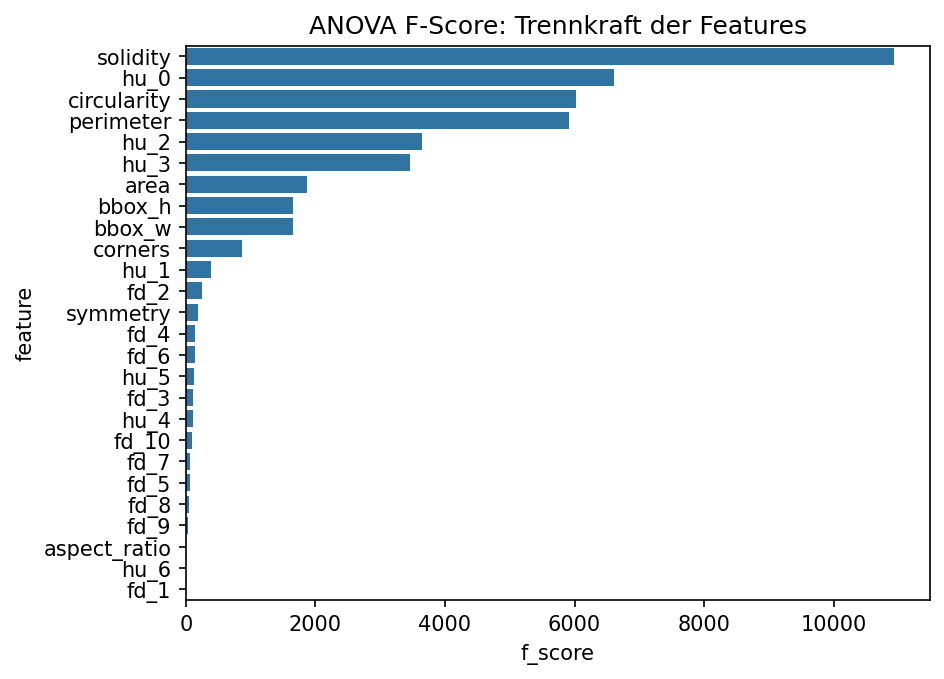

In [14]:
from sklearn.feature_selection import f_classif

X = df.drop(columns=["label", "name", "group"], errors="ignore")
y = df["label"]

f_scores, p_values = f_classif(X, y)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "f_score": f_scores,
    "p_value": p_values
}).sort_values("f_score", ascending=False)

print(importance_df)

# Als Plot
sns.barplot(data=importance_df, x="f_score", y="feature")
plt.title("ANOVA F-Score: Trennkraft der Features")
plt.show()

In [15]:
selected_features = ["hu_3", "solidity", "perimeter"]  #  "corners", "fd_4","perimeter",  "circularity",    "hu_4",  "fd_2","bbox_w",  "fd_3",  "fd_5",  "hu_1","solidity","fd_7",  "fd_6", "hu_0", "hu_2", "hu_3","hu_5","hu_6", "fd_1", "area"


from sklearn.model_selection import GroupShuffleSplit

df['group'] = df['name'].str.extract(r'^(.+?)_(?:rot|mir)')

X = df[selected_features]
y = df["label"]
groups = df['group']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

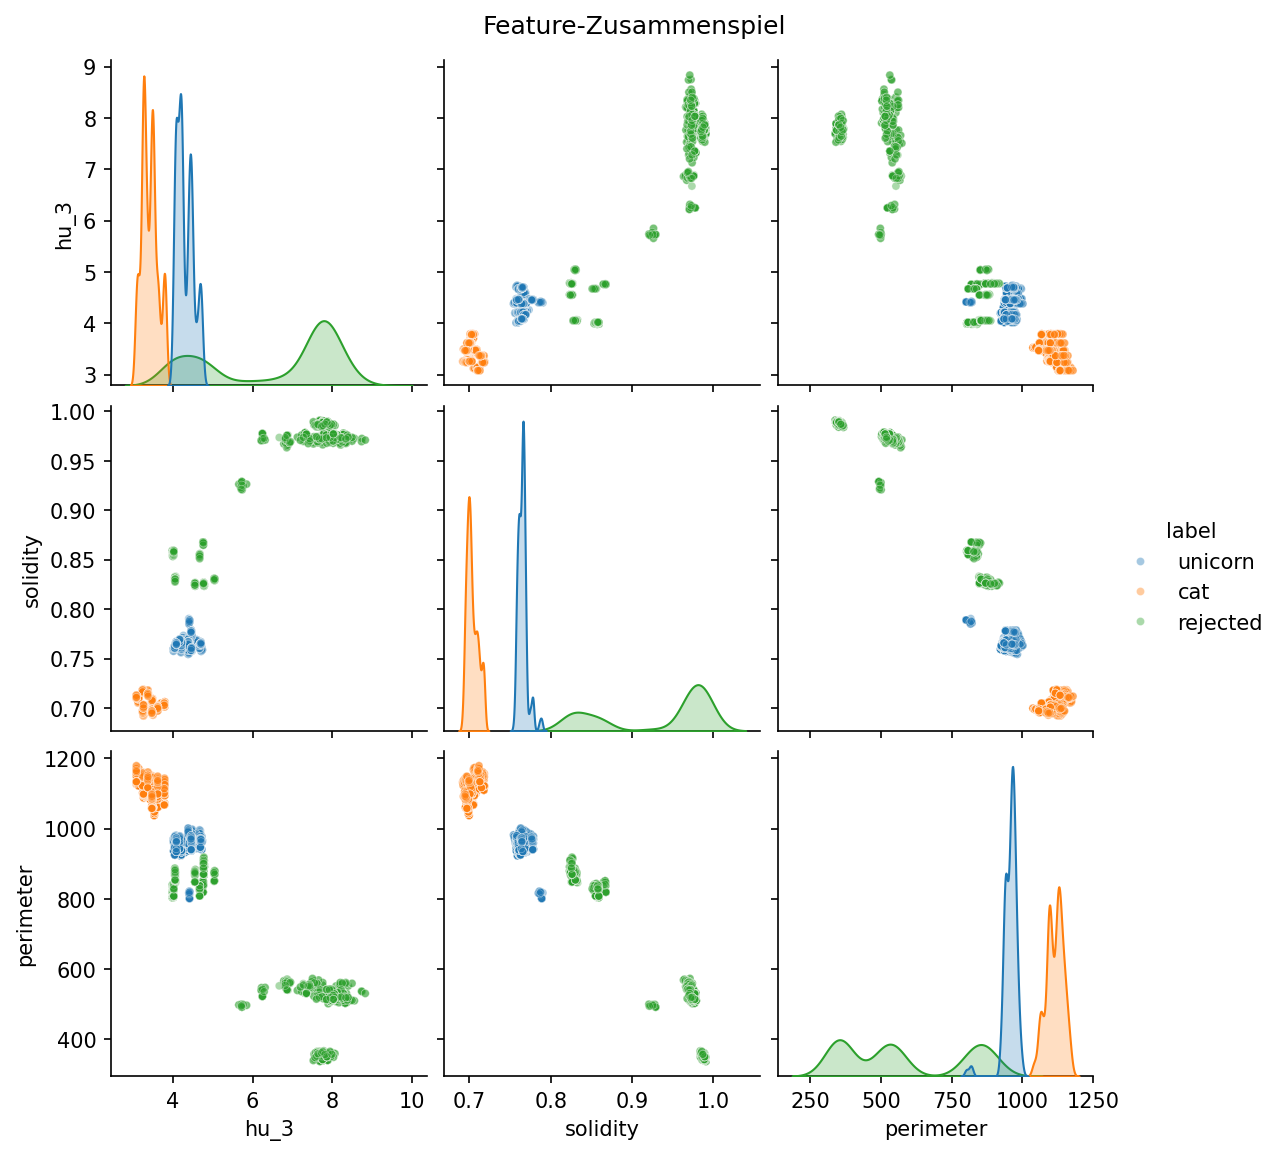

In [16]:
sns.pairplot(
    df[selected_features + ["label"]], 
    hue="label",
    plot_kws={"alpha": 0.4, "s": 15},
    diag_kind="kde"  # Verteilung auf der Diagonale
)
plt.suptitle("Feature-Zusammenspiel", y=1.02)
plt.show()

In [17]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=31
)
model.fit(X_train, y_train) 

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,31
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [18]:
X_test

,hu_3,solidity,perimeter
168,4.474369,0.766879,954.790973
169,4.478496,0.765625,986.277466
170,4.478925,0.766347,982.766628
171,4.474369,0.766879,954.790973
172,4.460791,0.764085,988.533792
...,...,...,...
3379,7.715621,0.986994,360.063357
3380,7.817599,0.985271,361.803511
3381,7.762174,0.990112,343.906635
3382,7.632019,0.987024,354.259714


In [19]:
pred = model.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

         cat       1.00      1.00      1.00       192
    rejected       1.00      1.00      1.00       264
     unicorn       1.00      1.00      1.00       264

    accuracy                           1.00       720
   macro avg       1.00      1.00      1.00       720
weighted avg       1.00      1.00      1.00       720



In [20]:
joblib.dump(model, "decision_tree.joblib")
print("Model saved.")

Model saved.


In [21]:
model = joblib.load("decision_tree.joblib") 

In [22]:
contours_obj


(array([[[ 387, 1205]]], dtype=int32),
 array([[[ 133, 1205]]], dtype=int32),
 array([[[ 342, 1204]],
 
        [[ 342, 1205]],
 
        [[ 343, 1205]]], dtype=int32),
 array([[[ 240, 1204]],
 
        [[ 239, 1205]]], dtype=int32),
 array([[[ 167, 1204]]], dtype=int32),
 array([[[ 143, 1204]],
 
        [[ 142, 1205]],
 
        [[ 143, 1205]],
 
        [[ 144, 1205]],
 
        [[ 144, 1204]]], dtype=int32),
 array([[[ 125, 1204]],
 
        [[ 125, 1205]],
 
        [[ 126, 1205]],
 
        [[ 127, 1205]],
 
        [[ 128, 1205]],
 
        [[ 127, 1204]],
 
        [[ 126, 1204]]], dtype=int32),
 array([[[  72, 1204]]], dtype=int32),
 array([[[   0, 1204]],
 
        [[   0, 1205]]], dtype=int32),
 array([[[ 329, 1203]],
 
        [[ 330, 1203]]], dtype=int32),
 array([[[  95, 1203]],
 
        [[  94, 1204]],
 
        [[  93, 1205]],
 
        [[  94, 1205]],
 
        [[  95, 1205]],
 
        [[  96, 1204]],
 
        [[  96, 1203]]], dtype=int32),
 array([[[  79, 1203]],
 

In [23]:
def extract_hu2_hu3_features(cnt):
    """Extrahiert nur die Hu-Momente 2 und 3 aus einer Kontur."""
    features = {}

    M_moments = cv.moments(cnt)
    if M_moments["m00"] == 0:
        return None

    hu_raw = cv.HuMoments(cv.moments(cnt)).flatten()

    with np.errstate(divide="ignore"):
        # Logarithmische Transformation wie im Original
        hu_log = -np.sign(hu_raw) * np.log10(np.abs(hu_raw) + 1e-10)

    features["hu_2"] = float(hu_log[2])  
    features["hu_3"] = float(hu_log[3])

    return features

In [24]:
import pandas as pd

# 1. Größte Kontur
cnt = max(contours_obj, key=cv.contourArea)

# 2. Features extrahieren
features = extract_hu2_hu3_features(cnt)

# 3. Als DataFrame – Spaltenreihenfolge muss mit selected_features übereinstimmen
X_new = pd.DataFrame([features])[selected_features]  # ["hu_2", "hu_3"]

# 4. Vorhersage
prediction = model.predict(X_new)
print("Erkannte Klasse:", prediction[0])

# Optional: Wahrscheinlichkeiten pro Klasse
proba = model.predict_proba(X_new)
print("Konfidenz:", dict(zip(model.classes_, proba[0].round(2))))

KeyError: "['solidity', 'perimeter'] not in index"